In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

X = np.load("/content/drive/MyDrive/Mammogram_Project/density_roi_x.npy")
Y = np.load("/content/drive/MyDrive/Mammogram_Project/density_roi_y.npy")
D = np.load("/content/drive/MyDrive/Mammogram_Project/density_labels.npy")

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# First split: 80% train, 20% temp
X_train, X_temp, Y_train, Y_temp, D_train, D_temp = train_test_split(
    X,
    Y,
    D,
    test_size=0.20,
    random_state=42,
    stratify=D
)

# Second split: temp -> 10% val, 10% test
X_val, X_test, Y_val, Y_test, D_val, D_test = train_test_split(
    X_temp,
    Y_temp,
    D_temp,
    test_size=0.50,
    random_state=42,
    stratify=D_temp
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (1356, 224, 224)
Val  : (170, 224, 224)
Test : (170, 224, 224)


In [4]:
def show_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name}")
    for u, c in zip(unique, counts):
        print(f"Density {u}: {c}")

show_distribution("Train", D_train)
show_distribution("Validation", D_val)
show_distribution("Test", D_test)


Train
Density 1: 270
Density 2: 605
Density 3: 359
Density 4: 122

Validation
Density 1: 33
Density 2: 76
Density 3: 45
Density 4: 16

Test
Density 1: 34
Density 2: 76
Density 3: 45
Density 4: 15


In [5]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

In [6]:
Y_train = Y_train.astype(np.float32)
Y_val   = Y_val.astype(np.float32)
Y_test  = Y_test.astype(np.float32)

In [7]:
X_train = np.expand_dims(X_train,1)
Y_train = np.expand_dims(Y_train,1)

X_val = np.expand_dims(X_val,1)
Y_val = np.expand_dims(Y_val,1)

X_test = np.expand_dims(X_test,1)
Y_test = np.expand_dims(Y_test,1)

In [8]:
print("X_train :", X_train.shape)
print("Y_train :", Y_train.shape)

print("X_val :", X_val.shape)
print("Y_val :", Y_val.shape)

print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)

X_train : (1356, 1, 224, 224)
Y_train : (1356, 1, 224, 224)
X_val : (170, 1, 224, 224)
Y_val : (170, 1, 224, 224)
X_test : (170, 1, 224, 224)
Y_test : (170, 1, 224, 224)


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

In [36]:
from torch.utils.data import Dataset

class MammogramDataset(Dataset):

    def __init__(self, images, masks, labels):
        self.images = images
        self.masks = masks
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        )

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        )

        density = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, mask, density

In [37]:
train_dataset = MammogramDataset(
    X_train,
    Y_train,
    D_train
)

val_dataset = MammogramDataset(
    X_val,
    Y_val,
    D_val
)

test_dataset = MammogramDataset(
    X_test,
    Y_test,
    D_test
)

In [38]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [40]:
batch = next(iter(test_loader))
print(len(batch))

3


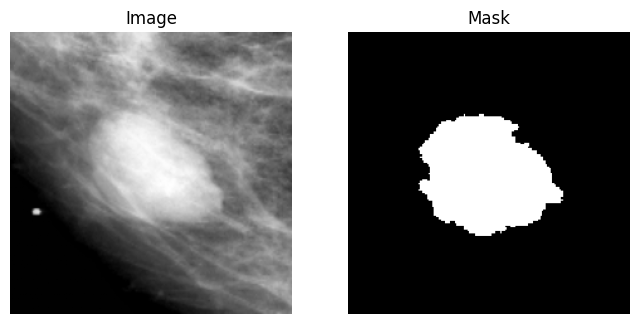

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[0,0], cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[0,0], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [15]:
print(torch.unique(masks))

tensor([0., 1.])


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [18]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [19]:
class UpConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2,
                        mode='bilinear',
                        align_corners=True),

            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3,
                      padding=1),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.up(x)

In [20]:
class AttentionUNet(nn.Module):

    def __init__(self, img_ch=1, output_ch=1):

        super().__init__()

        self.Maxpool = nn.MaxPool2d(2)

        self.Conv1 = DoubleConv(img_ch,64)
        self.Conv2 = DoubleConv(64,128)
        self.Conv3 = DoubleConv(128,256)
        self.Conv4 = DoubleConv(256,512)
        self.Conv5 = DoubleConv(512,1024)

        self.Up5 = UpConv(1024,512)
        self.Att5 = AttentionBlock(512,512,256)
        self.UpConv5 = DoubleConv(1024,512)

        self.Up4 = UpConv(512,256)
        self.Att4 = AttentionBlock(256,256,128)
        self.UpConv4 = DoubleConv(512,256)

        self.Up3 = UpConv(256,128)
        self.Att3 = AttentionBlock(128,128,64)
        self.UpConv3 = DoubleConv(256,128)

        self.Up2 = UpConv(128,64)
        self.Att2 = AttentionBlock(64,64,32)
        self.UpConv2 = DoubleConv(128,64)

        self.Conv_1x1 = nn.Conv2d(64, output_ch, kernel_size=1)

    def forward(self, x):

        x1 = self.Conv1(x)

        x2 = self.Maxpool(x1)
        x2 = self.Conv2(x2)

        x3 = self.Maxpool(x2)
        x3 = self.Conv3(x3)

        x4 = self.Maxpool(x3)
        x4 = self.Conv4(x4)

        x5 = self.Maxpool(x4)
        x5 = self.Conv5(x5)

        d5 = self.Up5(x5)
        x4 = self.Att5(d5,x4)
        d5 = torch.cat((x4,d5),dim=1)
        d5 = self.UpConv5(d5)

        d4 = self.Up4(d5)
        x3 = self.Att4(d4,x3)
        d4 = torch.cat((x3,d4),dim=1)
        d4 = self.UpConv4(d4)

        d3 = self.Up3(d4)
        x2 = self.Att3(d3,x2)
        d3 = torch.cat((x2,d3),dim=1)
        d3 = self.UpConv3(d3)

        d2 = self.Up2(d3)
        x1 = self.Att2(d2,x1)
        d2 = torch.cat((x1,d2),dim=1)
        d2 = self.UpConv2(d2)

        out = self.Conv_1x1(d2)

        return out

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet(
    img_ch=1,
    output_ch=1
).to(device)

print(device)

cuda


In [22]:
x = torch.randn(2,1,224,224).to(device)

with torch.no_grad():
    y = model(x)

print("Input :", x.shape)
print("Output:", y.shape)

Input : torch.Size([2, 1, 224, 224])
Output: torch.Size([2, 1, 224, 224])


In [23]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (2. * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [24]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def criterion(pred, target):

    bce = bce_loss(pred, target)
    dice = dice_loss(pred, target)

    return 0.5*bce + 0.5*dice

In [25]:
import numpy as np

def calculate_metrics(pred, target):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.cpu().numpy().flatten()
    target = target.cpu().numpy().flatten()

    TP = np.sum((pred==1) & (target==1))
    TN = np.sum((pred==0) & (target==0))
    FP = np.sum((pred==1) & (target==0))
    FN = np.sum((pred==0) & (target==1))

    accuracy = (TP+TN)/(TP+TN+FP+FN+1e-8)

    precision = TP/(TP+FP+1e-8)

    recall = TP/(TP+FN+1e-8)

    f1 = 2*precision*recall/(precision+recall+1e-8)

    iou = TP/(TP+FP+FN+1e-8)

    dice = (2*TP)/(2*TP+FP+FN+1e-8)

    return accuracy, precision, recall, f1, iou, dice

In [26]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [27]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": []
}

In [28]:
EPOCHS = 50

best_dice = 0.0
patience = 10
counter = 0

SAVE_PATH = "/content/drive/MyDrive/Mammogram_Project/best_attention_unet.pth"

In [29]:
from tqdm import tqdm
import torch
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################

    model.train()

    train_loss = 0

    train_acc = 0
    train_prec = 0
    train_rec = 0
    train_f1 = 0
    train_iou = 0
    train_dice = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(outputs.detach(), masks)

        train_acc += acc
        train_prec += prec
        train_rec += rec
        train_f1 += f1
        train_iou += iou
        train_dice += dice

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_prec /= len(train_loader)
    train_rec /= len(train_loader)
    train_f1 /= len(train_loader)
    train_iou /= len(train_loader)
    train_dice /= len(train_loader)

    ########################################
    # VALIDATION
    ########################################

    model.eval()

    val_loss = 0

    val_acc = 0
    val_prec = 0
    val_rec = 0
    val_f1 = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

            acc, prec, rec, f1, iou, dice = calculate_metrics(outputs, masks)

            val_acc += acc
            val_prec += prec
            val_rec += rec
            val_f1 += f1
            val_iou += iou
            val_dice += dice

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_prec /= len(val_loader)
    val_rec /= len(val_loader)
    val_f1 /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    ########################################
    # STORE HISTORY
    ########################################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    history["train_recall"].append(train_rec)
    history["val_recall"].append(val_rec)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    ########################################
    # SCHEDULER
    ########################################

    scheduler.step(val_dice)

    ########################################
    # SAVE BEST MODEL
    ########################################

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save(model.state_dict(), SAVE_PATH)

    else:

        counter += 1

    ########################################
    # PRINT
    ########################################

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f} | Val Dice : {val_dice:.4f}")

    print(f"Train IoU  : {train_iou:.4f} | Val IoU  : {val_iou:.4f}")

    print(f"Train Acc  : {train_acc:.4f} | Val Acc  : {val_acc:.4f}")

    print(f"Train Prec : {train_prec:.4f} | Val Prec : {val_prec:.4f}")

    print(f"Train Rec  : {train_rec:.4f} | Val Rec  : {val_rec:.4f}")

    print(f"Train F1   : {train_f1:.4f} | Val F1   : {val_f1:.4f}")

    ########################################
    # EARLY STOPPING
    ########################################

    if counter >= patience:

        print("\nEarly stopping triggered!")

        break

print("\nTraining Finished!")
print("Best Validation Dice :", best_dice)

/tmp/ipykernel_1653/3856930561.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/170 [00:00<?, ?it/s]/tmp/ipykernel_1653/3856930561.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 170/170 [00:42<00:00,  4.00it/s]



Epoch [1/50]
Train Loss : 0.4777 | Val Loss : 0.4205
Train Dice : 0.7093 | Val Dice : 0.7917
Train IoU  : 0.5596 | Val IoU  : 0.6581
Train Acc  : 0.9409 | Val Acc  : 0.9652
Train Prec : 0.6212 | Val Prec : 0.7403
Train Rec  : 0.8537 | Val Rec  : 0.8568
Train F1   : 0.7093 | Val F1   : 0.7917


100%|██████████| 170/170 [00:42<00:00,  3.97it/s]



Epoch [2/50]
Train Loss : 0.3885 | Val Loss : 0.4248
Train Dice : 0.7847 | Val Dice : 0.6874
Train IoU  : 0.6485 | Val IoU  : 0.5260
Train Acc  : 0.9629 | Val Acc  : 0.9338
Train Prec : 0.7246 | Val Prec : 0.5401
Train Rec  : 0.8719 | Val Rec  : 0.9522
Train F1   : 0.7847 | Val F1   : 0.6874


100%|██████████| 170/170 [00:44<00:00,  3.81it/s]


...


Epoch [36/50]
Train Loss : 0.0588 | Val Loss : 0.1094
Train Dice : 0.9411 | Val Dice : 0.8797
Train IoU  : 0.8889 | Val IoU  : 0.7864
Train Acc  : 0.9907 | Val Acc  : 0.9811
Train Prec : 0.9387 | Val Prec : 0.8942
Train Rec  : 0.9449 | Val Rec  : 0.8679
Train F1   : 0.9411 | Val F1   : 0.8797


100%|██████████| 170/170 [00:44<00:00,  3.82it/s]



Epoch [37/50]
Train Loss : 0.0571 | Val Loss : 0.1082
Train Dice : 0.9432 | Val Dice : 0.8807
Train IoU  : 0.8927 | Val IoU  : 0.7880
Train Acc  : 0.9911 | Val Acc  : 0.9813
Train Prec : 0.9419 | Val Prec : 0.8941
Train Rec  : 0.9457 | Val Rec  : 0.8699
Train F1   : 0.9432 | Val F1   : 0.8807


100%|██████████| 170/170 [00:44<00:00,  3.83it/s]



Epoch [38/50]
Train Loss : 0.0559 | Val Loss : 0.1084
Train Dice : 0.9445 | Val Dice : 0.8812
Train IoU  : 0.8951 | Val IoU  : 0.7887
Train Acc  : 0.9913 | Val Acc  : 0.9813
Train Prec : 0.9426 | Val Prec : 0.8892
Train Rec  : 0.9476 | Val Rec  : 0.8756
Train F1   : 0.9445 | Val F1   : 0.8812

Early stopping triggered!

Training Finished!
Best Validation Dice : 0.8840185287945037


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Mammogram_Project/best_attention_unet.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [42]:
test_loss = 0

test_acc = 0
test_prec = 0
test_rec = 0
test_f1 = 0
test_iou = 0
test_dice = 0

all_preds = []
all_masks = []
all_density = []

with torch.no_grad():

    for images, masks, density in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        test_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(outputs, masks)

        test_acc += acc
        test_prec += prec
        test_rec += rec
        test_f1 += f1
        test_iou += iou
        test_dice += dice

        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.append(preds.cpu())
        all_masks.append(masks.cpu())
        all_density.append(density)

In [43]:
test_loss /= len(test_loader)
test_acc  /= len(test_loader)
test_prec /= len(test_loader)
test_rec  /= len(test_loader)
test_f1   /= len(test_loader)
test_iou  /= len(test_loader)
test_dice /= len(test_loader)

print("="*50)
print("TEST RESULTS")
print("="*50)

print(f"Loss      : {test_loss:.4f}")
print(f"Dice      : {test_dice:.4f}")
print(f"IoU       : {test_iou:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

TEST RESULTS
Loss      : 0.1107
Dice      : 0.8790
IoU       : 0.7853
Accuracy  : 0.9811
Precision : 0.8907
Recall    : 0.8704
F1 Score  : 0.8790


In [44]:
all_preds = torch.cat(all_preds, dim=0)
all_masks = torch.cat(all_masks, dim=0)
all_density = torch.cat(all_density, dim=0)

print(all_preds.shape)
print(all_masks.shape)
print(all_density.shape)

torch.Size([170, 1, 224, 224])
torch.Size([170, 1, 224, 224])
torch.Size([170])


In [45]:
import pandas as pd

results = []

for d in [1, 2, 3, 4]:

    idx = (all_density == d)

    pred = all_preds[idx]
    gt = all_masks[idx]

    acc, prec, rec, f1, iou, dice = calculate_metrics(pred, gt)

    results.append({
        "Density": d,
        "Samples": len(pred),
        "Dice": round(dice,4),
        "IoU": round(iou,4),
        "Accuracy": round(acc,4),
        "Precision": round(prec,4),
        "Recall": round(rec,4),
        "F1": round(f1,4)
    })

density_df = pd.DataFrame(results)

density_df

,Density,Samples,Dice,IoU,Accuracy,Precision,Recall,F1
0,1,34,0.8691,0.7685,0.9833,0.8653,0.8730,0.8691
1,2,76,0.8808,0.7870,0.9805,0.9128,0.8509,0.8808
2,3,45,0.8810,0.7873,0.9819,0.8761,0.8859,0.8810
3,4,15,0.8598,0.7541,0.9740,0.8335,0.8878,0.8598


In [46]:
save_path = "/content/drive/MyDrive/Mammogram_Project/density_wise_results.csv"

density_df.to_csv(save_path, index=False)

print("Saved at:")
print(save_path)

Saved at:
/content/drive/MyDrive/Mammogram_Project/density_wise_results.csv


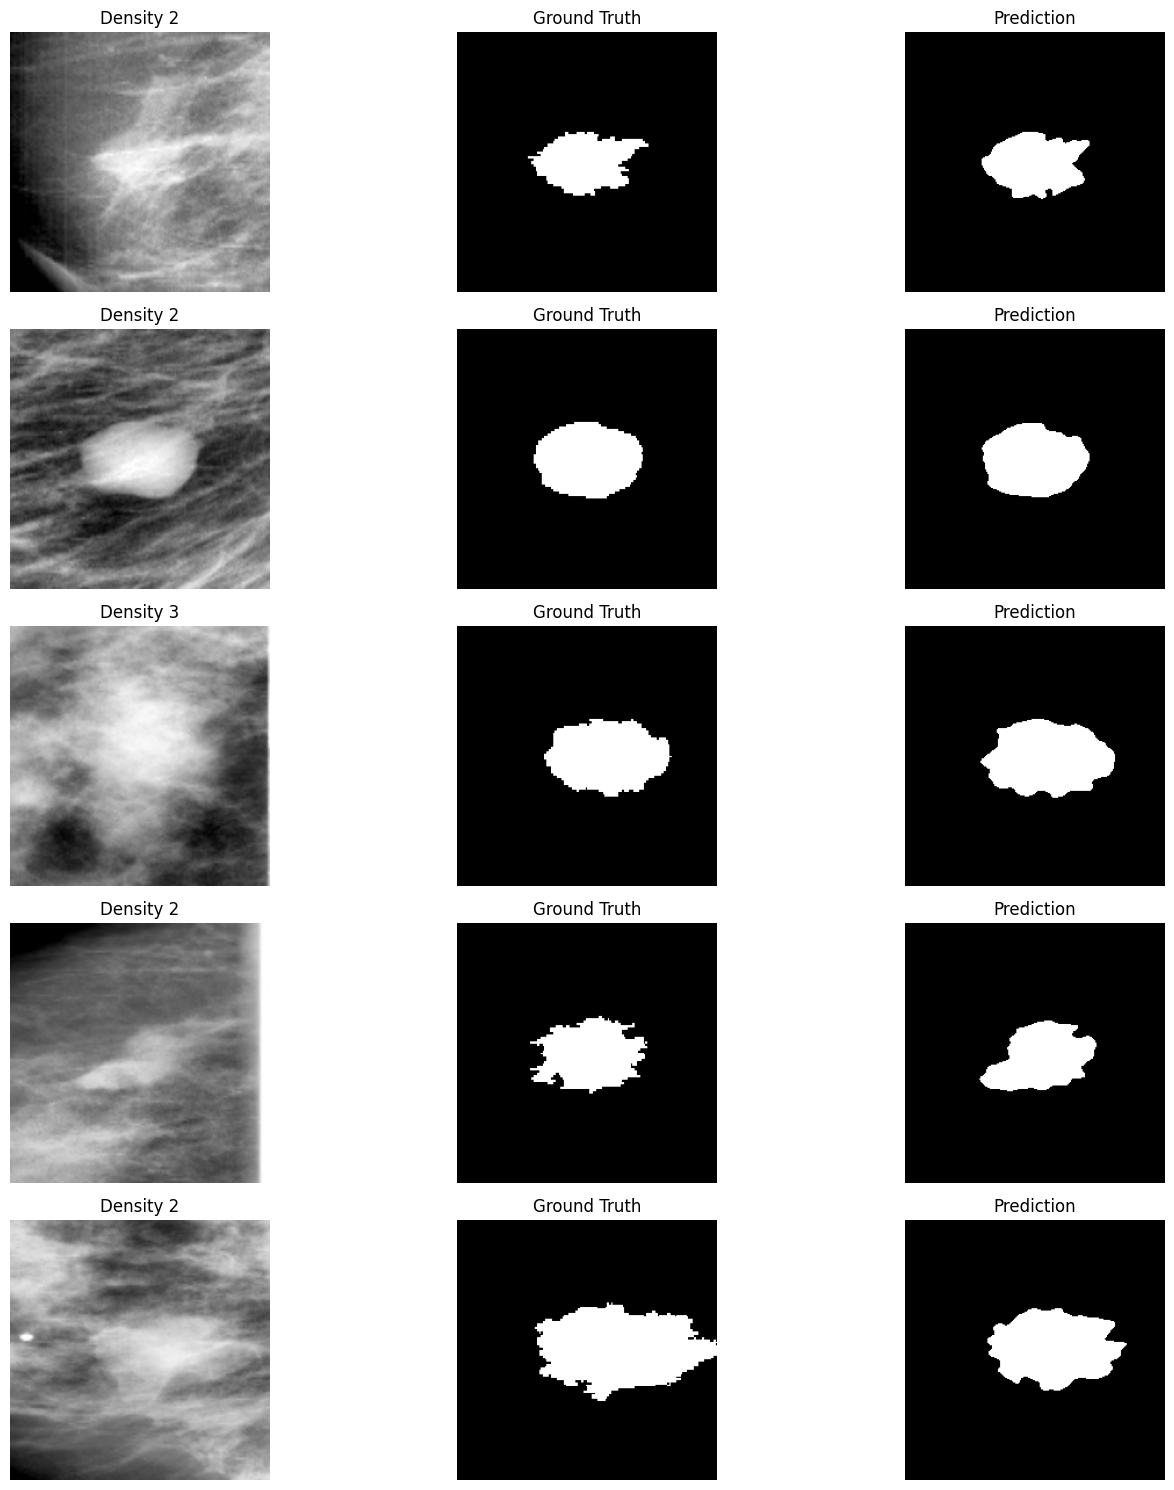

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import random

model.eval()

indices = random.sample(range(len(test_dataset)), 5)

plt.figure(figsize=(15,15))

for i, idx in enumerate(indices):

    image, mask, density = test_dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(pred) > 0.5).float()

    pred = pred.squeeze().cpu().numpy()

    plt.subplot(5,3,3*i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Density {density}")
    plt.axis("off")

    plt.subplot(5,3,3*i+2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5,3,3*i+3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

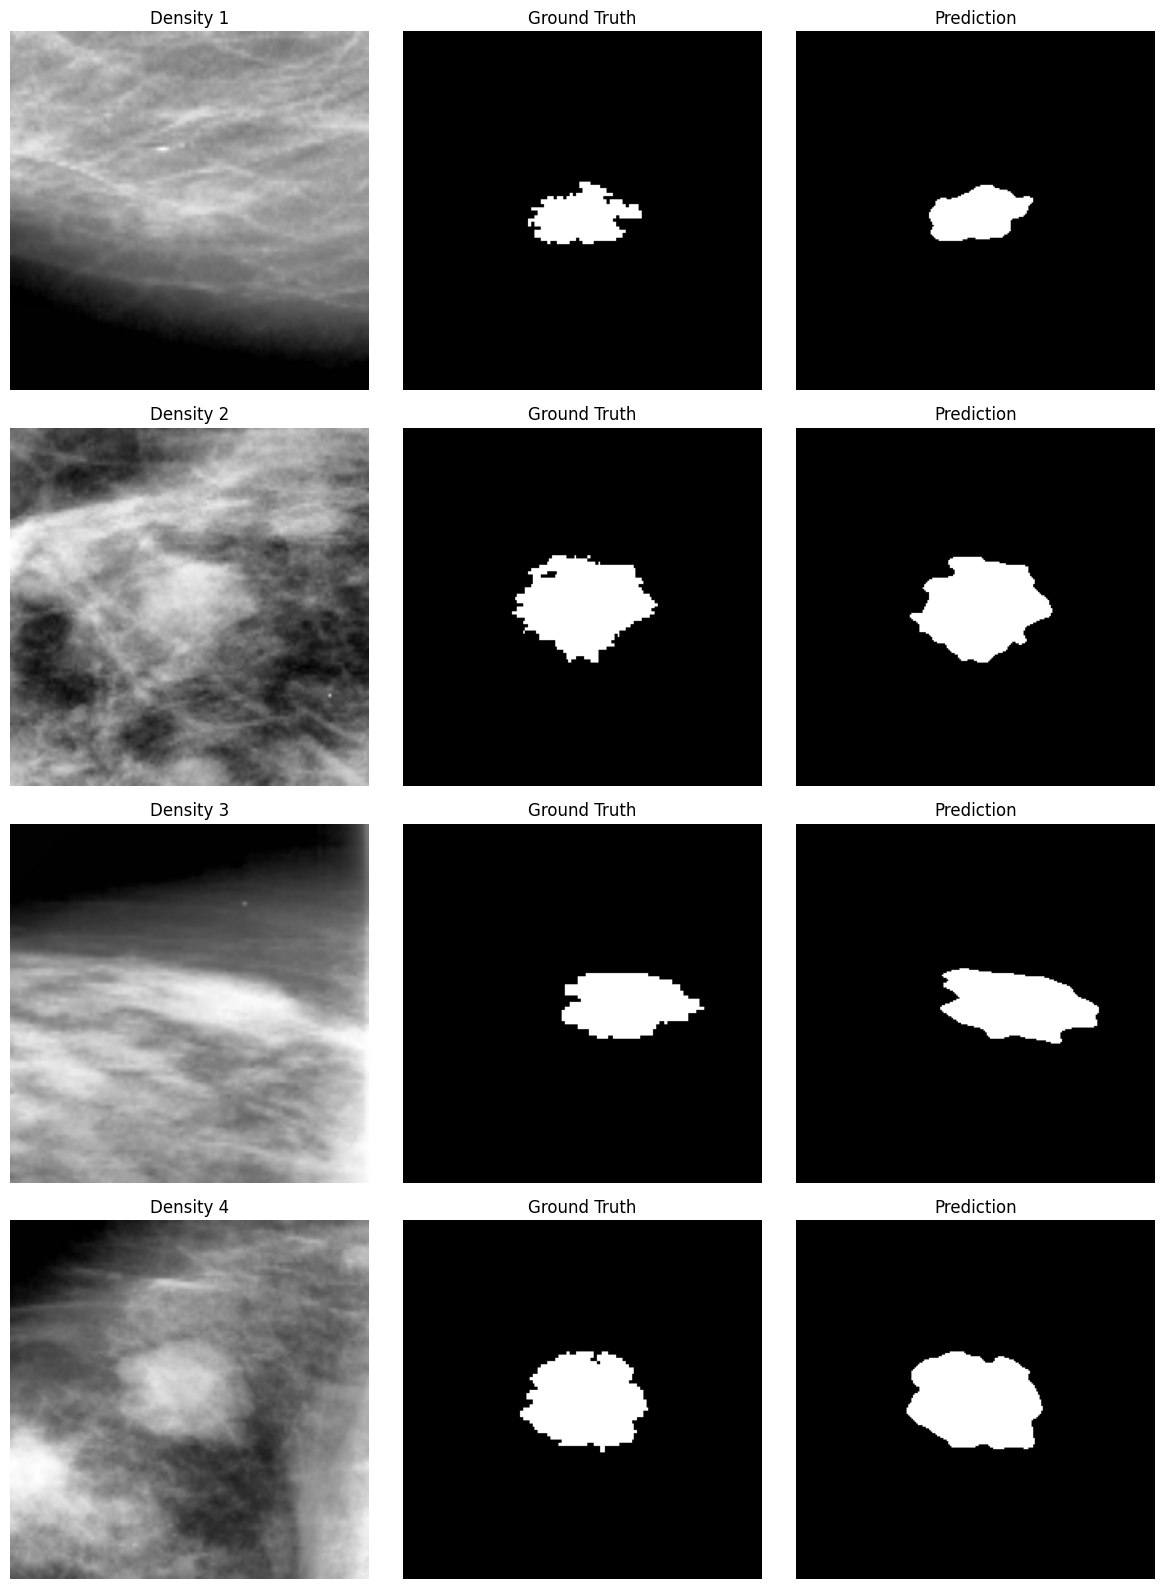

In [48]:
import matplotlib.pyplot as plt
import numpy as np

densities = [1,2,3,4]

plt.figure(figsize=(12,16))

row = 1

for d in densities:

    idx = np.where(D_test == d)[0][0]

    image, mask, density = test_dataset[idx]

    with torch.no_grad():

        pred = model(image.unsqueeze(0).to(device))
        pred = (torch.sigmoid(pred) > 0.5).float()

    pred = pred.squeeze().cpu().numpy()

    plt.subplot(4,3,row)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Density {d}")
    plt.axis("off")

    plt.subplot(4,3,row+1)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4,3,row+2)
    plt.imshow(pred,cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    row += 3

plt.tight_layout()
plt.show()

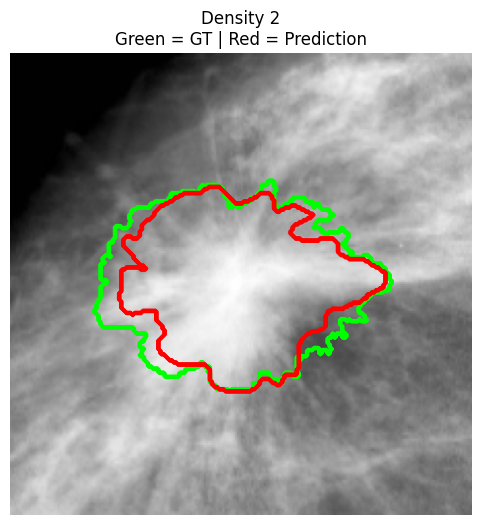

In [49]:
idx = np.random.randint(len(test_dataset))

image, mask, density = test_dataset[idx]

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))
    pred = (torch.sigmoid(pred) > 0.5).float()

pred = pred.squeeze().cpu().numpy()

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(image.squeeze(), cmap='gray')

ax.contour(mask.squeeze(), colors='lime', linewidths=2)

ax.contour(pred, colors='red', linewidths=2)

plt.title(f"Density {density}\nGreen = GT | Red = Prediction")

plt.axis("off")

plt.show()

In [50]:
import pandas as pd

metrics = pd.DataFrame({

    "Dataset":[
        "Train",
        "Validation",
        "Test"
    ],

    "Loss":[
        train_loss,
        val_loss,
        test_loss
    ],

    "Dice":[
        train_dice,
        val_dice,
        test_dice
    ],

    "IoU":[
        train_iou,
        val_iou,
        test_iou
    ],

    "Accuracy":[
        train_acc,
        val_acc,
        test_acc
    ],

    "Precision":[
        train_prec,
        val_prec,
        test_prec
    ],

    "Recall":[
        train_rec,
        val_rec,
        test_rec
    ],

    "F1":[
        train_f1,
        val_f1,
        test_f1
    ]
})

metrics

,Dataset,Loss,Dice,IoU,Accuracy,Precision,Recall,F1
0,Train,0.055928,0.944550,0.895093,0.991326,0.942641,0.947557,0.944550
1,Validation,0.108411,0.881155,0.788749,0.981287,0.889216,0.875616,0.881155
2,Test,0.110653,0.879035,0.785272,0.981079,0.890728,0.870416,0.879035


In [51]:
import numpy as np
import pandas as pd
from collections import defaultdict

def evaluate_density(model, loader):

    model.eval()

    dice_scores = defaultdict(list)
    iou_scores = defaultdict(list)

    with torch.no_grad():

        for images, masks, density in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            for i in range(images.size(0)):

                d = int(density[i])

                pred = preds[i].unsqueeze(0)
                gt = masks[i].unsqueeze(0)

                _, _, _, _, iou, dice = calculate_metrics(pred, gt)

                dice_scores[d].append(dice)
                iou_scores[d].append(iou)

    dice_mean = {}
    iou_mean = {}

    for d in [1,2,3,4]:

        dice_mean[d] = np.mean(dice_scores[d])
        iou_mean[d] = np.mean(iou_scores[d])

    return dice_mean, iou_mean

In [52]:
train_dice, train_iou = evaluate_density(model, train_loader)

val_dice, val_iou = evaluate_density(model, val_loader)

test_dice, test_iou = evaluate_density(model, test_loader)

In [53]:
density_table = pd.DataFrame({

    "Density":[1,2,3,4],

    "Train Dice":[
        train_dice[1],
        train_dice[2],
        train_dice[3],
        train_dice[4]
    ],

    "Val Dice":[
        val_dice[1],
        val_dice[2],
        val_dice[3],
        val_dice[4]
    ],

    "Test Dice":[
        test_dice[1],
        test_dice[2],
        test_dice[3],
        test_dice[4]
    ],

    "Train IoU":[
        train_iou[1],
        train_iou[2],
        train_iou[3],
        train_iou[4]
    ],

    "Val IoU":[
        val_iou[1],
        val_iou[2],
        val_iou[3],
        val_iou[4]
    ],

    "Test IoU":[
        test_iou[1],
        test_iou[2],
        test_iou[3],
        test_iou[4]
    ]

})

density_table = density_table.round(4)

density_table

,Density,Train Dice,Val Dice,Test Dice,Train IoU,Val IoU,Test IoU
0,1,0.9261,0.9030,0.8718,0.8644,0.8276,0.7774
1,2,0.9352,0.8893,0.8848,0.8794,0.8056,0.8009
2,3,0.9294,0.8685,0.8759,0.8701,0.7752,0.7840
3,4,0.9273,0.8781,0.8573,0.8656,0.7851,0.7560


In [54]:
save_path = "/content/drive/MyDrive/Mammogram_Project/Density_Wise_Train_Val_Test_Metrics.csv"

density_table.to_csv(save_path, index=False)

print("Saved Successfully!")
print(save_path)

Saved Successfully!
/content/drive/MyDrive/Mammogram_Project/Density_Wise_Train_Val_Test_Metrics.csv
